# Lab 4 — La película de tu parcela (serie temporal + clima)
**Módulo 5 · Clase 4 — Series temporales y clima**

Hoy el dato deja de ser una foto y se vuelve una **película**: la curva de NDVI de toda la campaña, explicada con el clima. Cuarto commit.

### Qué vas a hacer
1. Construir la **serie temporal de NDVI** de la parcela (acceso real, **sin login**, toda la campaña) desde el bucket público de AWS.
2. **Suavizar** la serie y leer su **forma fenológica** (trigo de invierno).
3. Descargar el **clima diario** de NASA POWER (abierto, sin credenciales).
4. **Alinear escalas** (clima diario ↔ NDVI cada ~5 días) y superponer.
5. Señalar al menos un **evento** (una caída de NDVI ligada al clima).

> **Acceso a datos — solo AWS.** Leemos Sentinel-2 L2A del bucket abierto `sentinel-cogs` (earth-search / Element84): sin cuenta, credenciales ni créditos — igual que los Labs 2 y 3. *(Las vías Copernicus openEO y Earth Engine se retiraron de este notebook.)*
>
> Recuerda la postura del módulo: un valor de NDVI **solo significa dentro de su curva**; la serie **localiza y prioriza** el cuándo, pero la causa se confirma en campo.

In [ ]:
pip install -q pystac-client odc-stac rioxarray xarray rasterio pandas numpy matplotlib requests

Note: you may need to restart the kernel to use updated packages.


In [ ]:

import os
# Acceso anónimo al bucket público sentinel-cogs (AWS). NO requiere credenciales.
os.environ["AWS_NO_SIGN_REQUEST"] = "YES"
os.environ["AWS_REGION"] = "us-west-2"
import numpy as np, pandas as pd, matplotlib.pyplot as plt, requests

BBOX=[-4.80,41.60,-4.60,41.80]
LAT=(BBOX[1]+BBOX[3])/2; LON=(BBOX[0]+BBOX[2])/2
CAMPANA=("2024-09-01","2025-07-31")
MAX_NUBES=40          # % de nube por escena para entrar en la serie
RESOL=60              # m/píxel: para la CURVA basta resolución gruesa (agregamos a la mediana de la parcela)
print("Parcela centro:",round(LAT,3),round(LON,3),"| campaña:",CAMPANA)

Matplotlib is building the font cache; this may take a moment.


Parcela centro: 41.7 -4.7 | campaña: ('2024-09-01', '2025-07-31')


## 1. Serie temporal de NDVI (acceso real — earth-search / AWS, sin login)
Buscamos **todas** las escenas de la campaña con nube < `MAX_NUBES`% y las apilamos en el tiempo con `odc-stac` (`groupby="solar_day"` une los tiles del mismo día). Pedimos solo `red` (B04), `nir` (B08) y `scl` (máscara). Para la curva de la parcela agregamos cada fecha a la **mediana** (estadístico robusto); la variabilidad espacial se conserva cuando interesa (Clase 3).

In [ ]:
from pystac_client import Client
from odc.stac import load as odc_load
EARTH_SEARCH="https://earth-search.aws.element84.com/v1"

def serie_ndvi_aws(min_valido=0.20):
    """NDVI medio (mediana espacial) de la parcela en toda la campaña, desde AWS (anónimo)."""
    cat=Client.open(EARTH_SEARCH)
    items=list(cat.search(collections=["sentinel-2-l2a"], bbox=BBOX,
        datetime=f"{CAMPANA[0]}/{CAMPANA[1]}",
        query={"eo:cloud_cover":{"lt":MAX_NUBES}}).items())
    if not items:
        raise RuntimeError("No hay escenas; sube MAX_NUBES o revisa BBOX/fechas.")
    print(f"Escenas candidatas (<{MAX_NUBES}% nube): {len(items)}")
    ds=odc_load(items, bands=["red","nir","scl"], bbox=BBOX,
                resolution=RESOL, groupby="solar_day")
    red=ds["red"].astype("float32")/10000.0
    nir=ds["nir"].astype("float32")/10000.0
    ndvi=(nir-red)/(nir+red)
    valid=ds["scl"].isin([4,5,7])                  # veg, suelo, sin-clasificar
    ndvi=ndvi.where(valid)
    frac=valid.mean(dim=["y","x"])                 # fracción de píxeles válidos por fecha
    serie=ndvi.median(dim=["y","x"], skipna=True)  # mediana espacial = NDVI de la parcela
    serie=serie.where(frac>=min_valido)            # descarta fechas casi todo-nube
    df=(serie.to_dataframe(name="ndvi").reset_index()[["time","ndvi"]]
          .rename(columns={"time":"fecha"}).dropna())
    df["fecha"]=pd.to_datetime(df["fecha"]).dt.tz_localize(None)
    return df.sort_values("fecha").reset_index(drop=True)

try:
    ndvi_df=serie_ndvi_aws()
    print("Serie real:", len(ndvi_df), "fechas |",
          ndvi_df["fecha"].min().date(), "->", ndvi_df["fecha"].max().date())
except Exception as ex:
    print("No se pudo construir la serie real ahora (", type(ex).__name__, ex, ")")
    print("-> Uso una curva sintética SOLO para ver el flujo. Sustitúyela por tu serie real antes de entregar.")
    f=pd.date_range(*CAMPANA,freq="10D")
    ndvi_df=pd.DataFrame({"fecha":f,
        "ndvi":np.clip(0.2+0.6*np.exp(-((np.arange(len(f))-22)/6)**2)+np.random.normal(0,0.03,len(f)),0,1)})
print(ndvi_df.head())

Escenas candidatas (<40% nube): 29
Serie real: 29 fechas | 2024-09-17 -> 2025-07-31
                    fecha      ndvi
0 2024-09-17 11:19:38.151  0.186018
1 2024-09-22 11:19:40.109  0.167480
2 2024-09-27 11:19:38.554  0.179198
3 2024-10-22 11:19:38.428  0.191720
4 2024-11-01 11:19:38.367  0.238491


## 2. Suavizar y leer la curva fenológica
La serie cruda tiembla (nubes residuales, ruido). Suavizamos con media móvil para ver la **forma**: meseta invernal → subida en abril → pico en mayo → senescencia en junio.


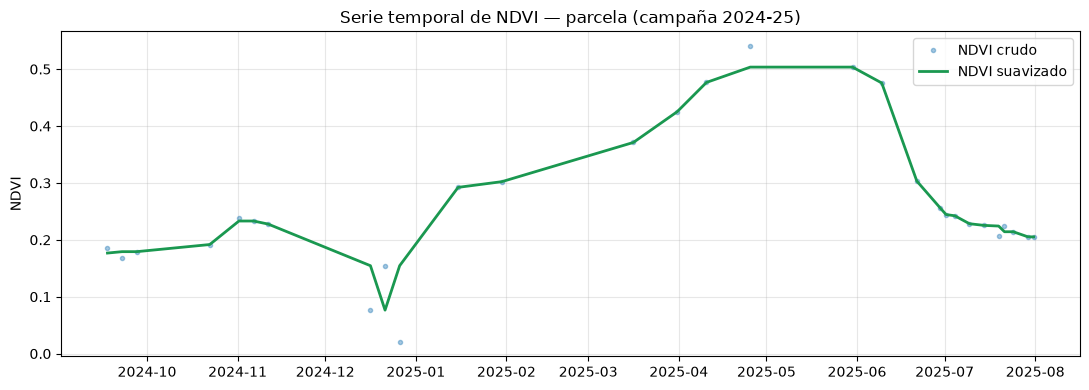

Pico de NDVI: 2025-04-25 -> 0.5


In [ ]:
ndvi_df["ndvi_suave"]=ndvi_df["ndvi"].rolling(3,center=True,min_periods=1).median()
plt.figure(figsize=(11,4))
plt.plot(ndvi_df["fecha"],ndvi_df["ndvi"],".",alpha=.4,label="NDVI crudo")
plt.plot(ndvi_df["fecha"],ndvi_df["ndvi_suave"],"-",lw=2,color="#1a9850",label="NDVI suavizado")
plt.ylabel("NDVI"); plt.title("Serie temporal de NDVI — parcela (campaña 2024-25)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

pico=ndvi_df.loc[ndvi_df["ndvi_suave"].idxmax()]
print("Pico de NDVI:",pico["fecha"].date(),"->",round(pico["ndvi_suave"],2))


## 3. Clima diario (NASA POWER — abierto, sin credenciales)
Descargamos temperatura (T2M), precipitación (PRECTOTCORR) y evapotranspiración de referencia (ET0) para el punto de la parcela.


In [ ]:
def nasa_power(lat,lon,ini,fin):
    url="https://power.larc.nasa.gov/api/temporal/daily/point"
    params=dict(parameters="T2M,T2M_MAX,PRECTOTCORR,EVPTRNS",
                community="AG", latitude=lat, longitude=lon,
                start=ini.replace("-",""), end=fin.replace("-",""), format="JSON")
    r=requests.get(url,params=params,timeout=60); r.raise_for_status()
    d=r.json()["properties"]["parameter"]
    df=pd.DataFrame(d); df.index=pd.to_datetime(df.index,format="%Y%m%d")
    return df.replace(-999,np.nan)

try:
    clima=nasa_power(LAT,LON,*CAMPANA)
    print(clima.describe().round(1))
except Exception as ex:
    print("No se pudo descargar NASA POWER ahora:",type(ex).__name__,ex)
    clima=None


         T2M  T2M_MAX  PRECTOTCORR  EVPTRNS
count  334.0    334.0        334.0    334.0
mean    12.5     18.9          1.6      0.9
std      6.9      7.9          3.2      1.3
min     -1.0      3.9          0.0      0.0
25%      7.2     12.2          0.0      0.1
50%     11.7     17.6          0.1      0.3
75%     17.1     24.2          1.7      1.3
max     28.5     37.4         17.7      5.6


## 4. Alinear escalas y superponer
El clima es **diario**; el NDVI viene **cada ~5 días con huecos**. Remuestreamos ambos a **semanal** y los dibujamos juntos. Una caída de NDVI tras lluvia escasa + calor sugiere **estrés hídrico** (no plaga).


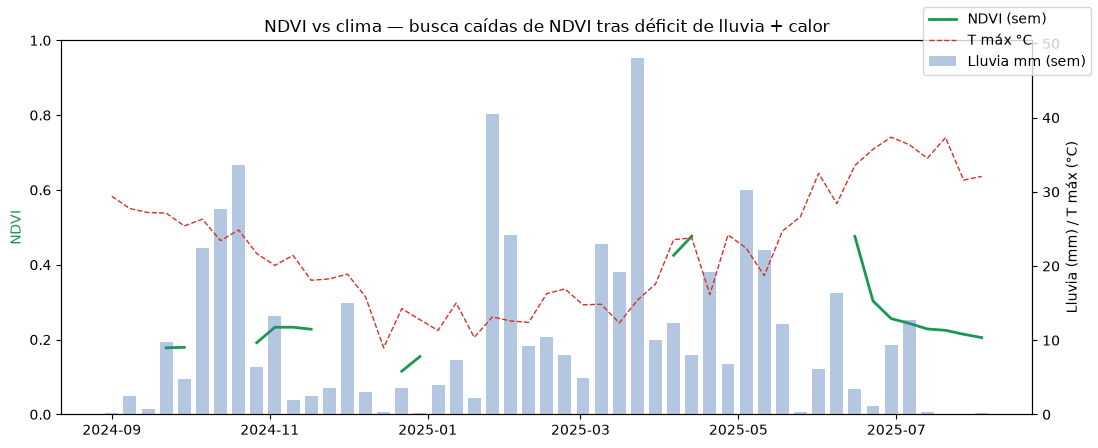

In [ ]:
if clima is not None:
    sem_clima=clima.resample("W").agg({"T2M_MAX":"max","PRECTOTCORR":"sum","EVPTRNS":"sum"})
    sem_ndvi=ndvi_df.set_index("fecha")["ndvi_suave"].resample("W").mean()

    fig,ax1=plt.subplots(figsize=(11,4.5))
    ax1.plot(sem_ndvi.index,sem_ndvi.values,"-",color="#1a9850",lw=2,label="NDVI (sem)")
    ax1.set_ylabel("NDVI",color="#1a9850"); ax1.set_ylim(0,1)
    ax2=ax1.twinx()
    ax2.bar(sem_clima.index,sem_clima["PRECTOTCORR"],width=5,alpha=.4,color="#4575b4",label="Lluvia mm (sem)")
    ax2.plot(sem_clima.index,sem_clima["T2M_MAX"],"--",color="#d73027",lw=1,label="T máx °C")
    ax2.set_ylabel("Lluvia (mm) / T máx (°C)")
    ax1.set_title("NDVI vs clima — busca caídas de NDVI tras déficit de lluvia + calor")
    fig.legend(loc="upper right"); plt.tight_layout(); plt.show()
else:
    print("Descarga primero el clima (sección 3).")


## 5. (Ruta B) Integral de NDVI ≈ biomasa
El área bajo la curva de NDVI a lo largo de la campaña correlaciona con la biomasa acumulada (Cap. 4.2). Con datos de cosecha podría calibrarse a rendimiento (eso es la Clase 5).


In [ ]:
dias=(ndvi_df["fecha"]-ndvi_df["fecha"].min()).dt.days.values
integral=np.trapezoid(ndvi_df["ndvi_suave"].values, dias)
print(f"Integral de NDVI (NDVI·día) en la campaña: {integral:.0f}")


Integral de NDVI (NDVI·día) en la campaña: 97
Úsala como proxy de biomasa acumulada; compárala entre zonas o campañas.


## 6. Preguntas para entregar
1. ¿La forma de tu serie NDVI coincide con la fenología esperada del trigo (meseta → subida abril → pico mayo → caída junio)? ¿Dónde se desvía?
2. ¿Hay alguna **caída de NDVI** que coincida con un periodo de poca lluvia y/o calor? ¿Qué hipótesis agronómica sugiere?
3. ¿Por qué hay que **remuestrear** antes de comparar NDVI y clima?
4. (Ruta B) ¿Qué te dice la integral de NDVI y para qué la usarías?

**Entrega:** notebook con serie NDVI + clima + lectura. **Cuarto commit.** Antes de la Clase 5 (25/06).